In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("./datasets/Coleta_Negras.csv")

In [37]:
df

,Name,Original_Text,Cor,Conclusao
0,Adriana Ramos,\nExcelentíssimo Senhor Doutor Juiz de Direito...,Negra,NaN
1,Adriana Ramos,Exmo. Sr. Dr. Juiz da MM 3a Vara do Trabalho ...,Negra,PERDIDO
2,Adriana Ramos,Fls.: 2 Exmo. Sr. Dr. Juiz da MM 3a Vara do T...,Negra,NaN
3,Adriana Ramos,Exmo. Sr. Dr. Juiz da MM. 3a Vara do Trabalho...,Negra,NaN
4,Adriana Ramos,Fls.: 2 EXMO (A). SR (A). DR (A). JUIZ (A) DO...,Negra,AMBIGUO
...,...,...,...,...
450,Washington Pires,EXCELENTÍSSIMO (a) SENHOR (a) DOUTOR (a) JUIZ...,Negra,NaN
451,Washington Pires,Número do documento: 22011417421066700007787...,Negra,NaN
452,Washington Pires,EXMO. DR. JUIZ DE DIREITO DA 2a VARA CÍVEL DA...,Negra,NaN
453,Washington Pires,COMARCA DE IBIRITÉ - MG Processo nº. 0000000-...,Negra,NaN


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           455 non-null    object
 1   Original_Text  455 non-null    object
 2   Cor            455 non-null    object
 3   Conclusao      134 non-null    object
dtypes: object(4)
memory usage: 14.3+ KB


In [39]:
situacao = df["Conclusao"].value_counts().reset_index()

In [40]:
situacao

,Conclusao,count
0,PERDIDO,65
1,AMBIGUO,43
2,GANHO,26


In [41]:
situacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Conclusao  3 non-null      object
 1   count      3 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes


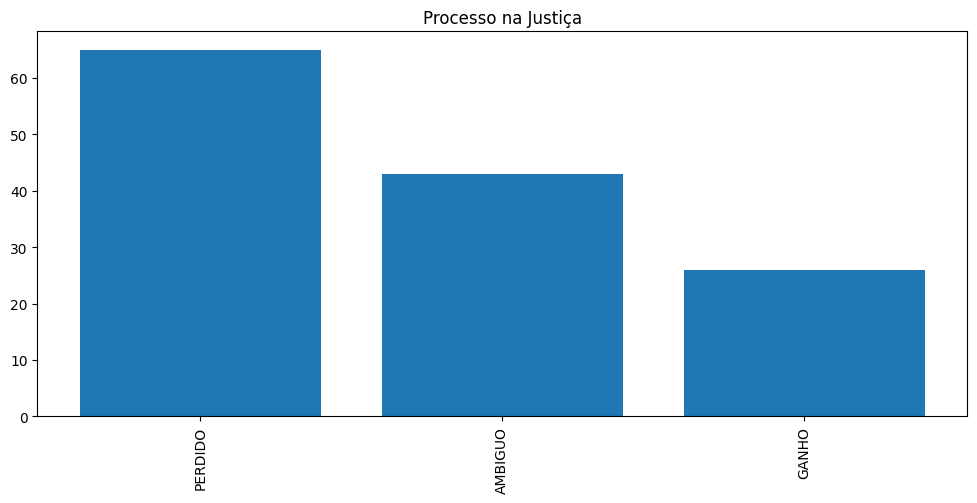

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.bar(situacao["Conclusao"], height=situacao["count"],)
plt.xticks(rotation=90)
# plt.bar()
ax.set_title("Processo na Justiça")
plt.show()

In [43]:
from nltk.stem import PorterStemmer
import nltk
from nltk.corpus import stopwords

# stopwords = nltk.download('stopwords')
stemmer = PorterStemmer()

## TF - IDF


In [44]:
df = df.dropna(subset="Conclusao")

In [45]:

from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,2) )
X = tf_idf.fit_transform(df["Original_Text"])
vocab = tf_idf.get_feature_names_out()

In [46]:
vocab

array(['00', '00 00', '00 000', ..., 'üri okfhj', 'üí', 'üí icinco'],
      dtype=object)

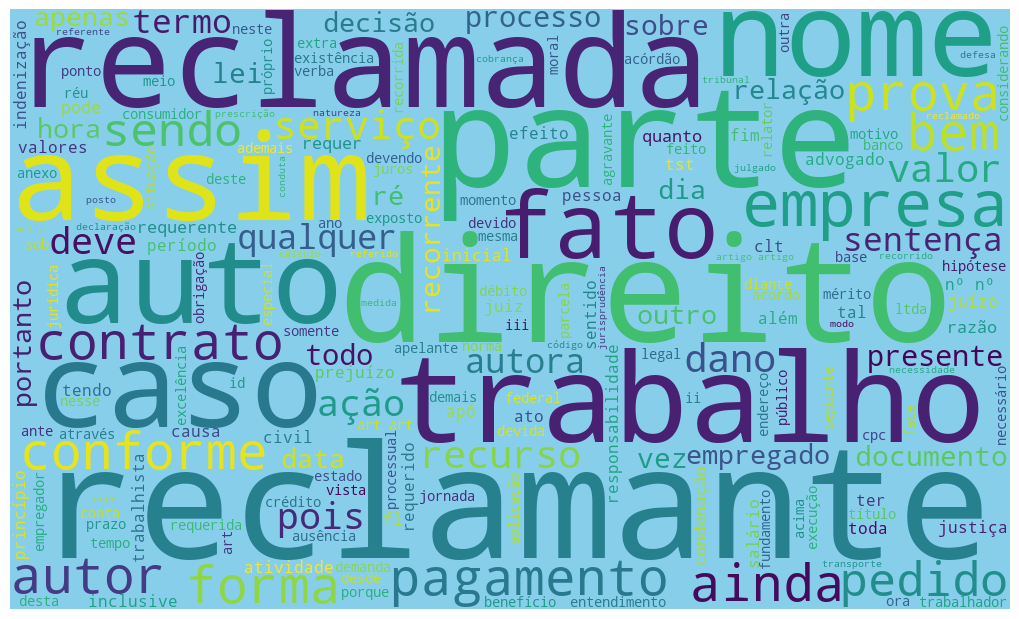

In [47]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud
vocab = ' '.join(vocab)

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='skyblue',
    min_font_size=10).generate(vocab)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [48]:
X

<134x170960 sparse matrix of type '<class 'numpy.float64'>'
	with 378339 stored elements in Compressed Sparse Row format>

In [49]:
df["Conclusao"]

1      PERDIDO
4      AMBIGUO
5      PERDIDO
27     PERDIDO
31       GANHO
        ...   
417    AMBIGUO
418    AMBIGUO
420      GANHO
440      GANHO
445    PERDIDO
Name: Conclusao, Length: 134, dtype: object

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Conclusao"] = le.fit_transform(df["Conclusao"])

C:\Users\alexa\AppData\Local\Temp\ipykernel_1588\3074434007.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Conclusao"] = le.fit_transform(df["Conclusao"])


In [51]:
df["Conclusao"]

1      2
4      0
5      2
27     2
31     1
      ..
417    0
418    0
420    1
440    1
445    2
Name: Conclusao, Length: 134, dtype: int32

In [89]:
from sklearn.decomposition import PCA, TruncatedSVD

pca = TruncatedSVD(n_components=3)

In [90]:
# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['Original_Text','Cor', "Conclusao"])
df_pca = df_pca.dropna(subset=["Conclusao"])



In [91]:
y = df["Conclusao"].reset_index(drop=True)

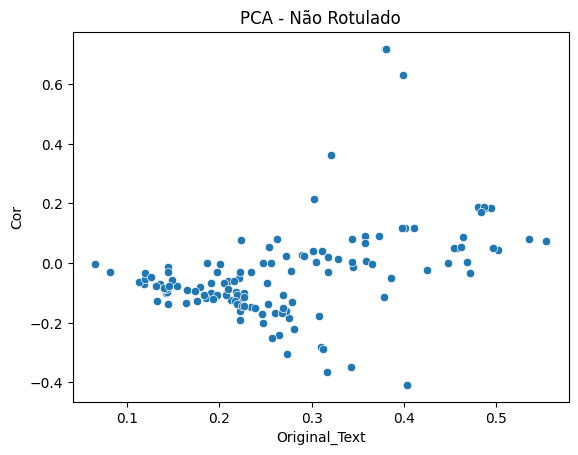

In [92]:



# Visualize the transformed data
sns.scatterplot(x='Original_Text', y="Cor", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

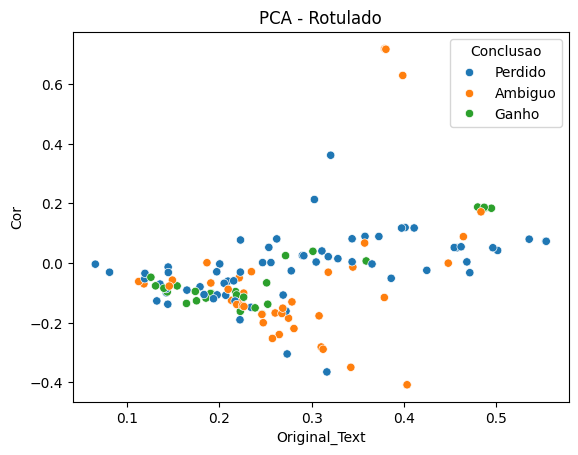

In [93]:
y_map = {0: 'Ambiguo', 1: "Ganho", 2: "Perdido"}


y = y.map(y_map)


df_pca["Conclusao"] = y

# Visualize the transformed data

sns.scatterplot(x='Original_Text', y="Cor", hue="Conclusao", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

# Treinar Modelo


In [94]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [95]:
X_train

<107x170960 sparse matrix of type '<class 'numpy.float64'>'
	with 309369 stored elements in Compressed Sparse Row format>

In [100]:
# Creating a function to display model results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Ambiguo", "Ganho", "Perdido"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

# Logistic Regression


In [101]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LogisticRegression(
    random_state=42, max_iter=1000, solver="lbfgs", penalty="l2", C=1, tol=0.0001)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.51851852 0.74074074 0.66666667 0.66666667 0.61538462]
Mean F1 Score: 0.6415954415954415


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.67      0.67      0.67         6
       Ganho       0.00      0.00      0.00         9
     Perdido       0.48      0.83      0.61        12

    accuracy                           0.52        27
   macro avg       0.38      0.50      0.42        27
weighted avg       0.36      0.52      0.42        27



c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

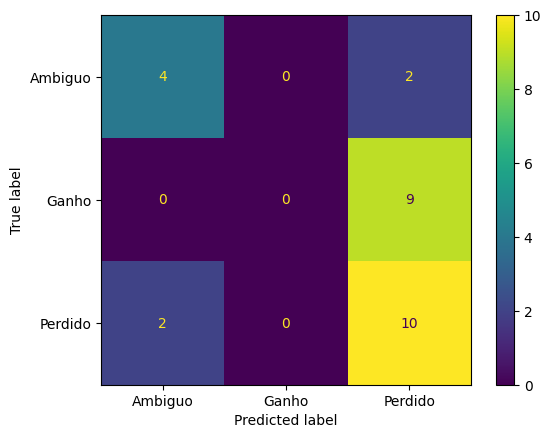

In [102]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier


In [103]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = SGDClassifier(random_state=42, alpha=0.0001, )

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.51851852 0.74074074 0.7037037  0.7037037  0.69230769]
Mean F1 Score: 0.6717948717948717


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.44      0.67      0.53         6
       Ganho       1.00      0.11      0.20         9
     Perdido       0.53      0.75      0.62        12

    accuracy                           0.52        27
   macro avg       0.66      0.51      0.45        27
weighted avg       0.67      0.52      0.46        27



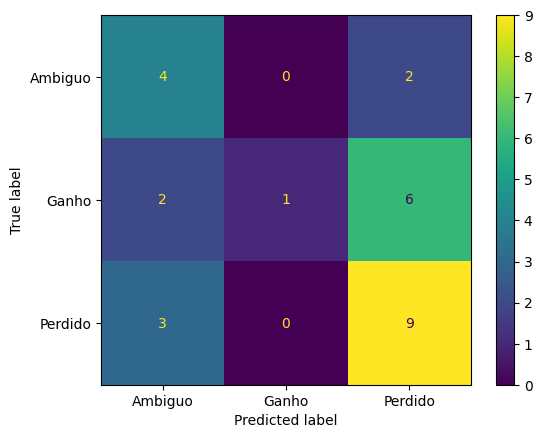

In [104]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# KNeighbors Classifier


In [105]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
# You can adjust the number of neighbors
model = KNeighborsClassifier(
    n_neighbors=1, weights="uniform", algorithm="brute", leaf_size=30, p=2)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.55555556 0.66666667 0.59259259 0.51851852 0.57692308]
Mean F1 Score: 0.5820512820512821


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.45      0.83      0.59         6
       Ganho       1.00      0.22      0.36         9
     Perdido       0.57      0.67      0.62        12

    accuracy                           0.56        27
   macro avg       0.68      0.57      0.52        27
weighted avg       0.69      0.56      0.53        27



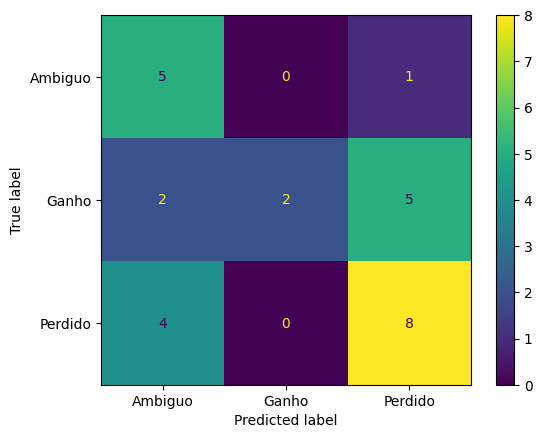

In [106]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - KNN", y_test, y_pred)

# SVC


In [107]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

K = 5

kf = KFold(n_splits=K, shuffle=True, random_state=42)


model = LinearSVC(penalty="l2", loss='squared_hinge',
                  tol=0.000001, C=10, multi_class='ovr', dual=True)


cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.51851852 0.77777778 0.62962963 0.66666667 0.69230769]
Mean F1 Score: 0.656980056980057


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.44      0.67      0.53         6
       Ganho       1.00      0.11      0.20         9
     Perdido       0.53      0.75      0.62        12

    accuracy                           0.52        27
   macro avg       0.66      0.51      0.45        27
weighted avg       0.67      0.52      0.46        27



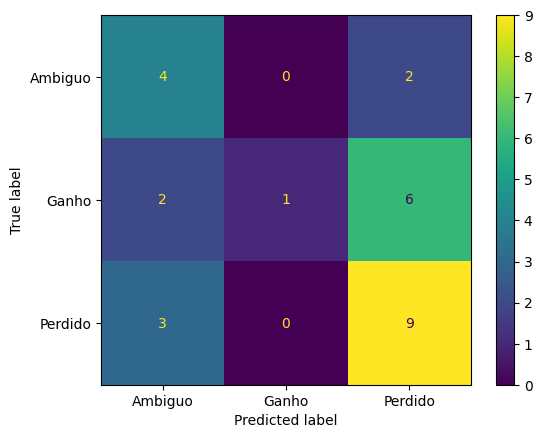

In [108]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest


In [109]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = RandomForestClassifier(
    n_estimators=100, criterion='log_loss', max_depth=None, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.55555556 0.81481481 0.74074074 0.7037037  0.65384615]
Mean F1 Score: 0.6937321937321936


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.75      0.50      0.60         6
       Ganho       1.00      0.11      0.20         9
     Perdido       0.50      0.92      0.65        12

    accuracy                           0.56        27
   macro avg       0.75      0.51      0.48        27
weighted avg       0.72      0.56      0.49        27



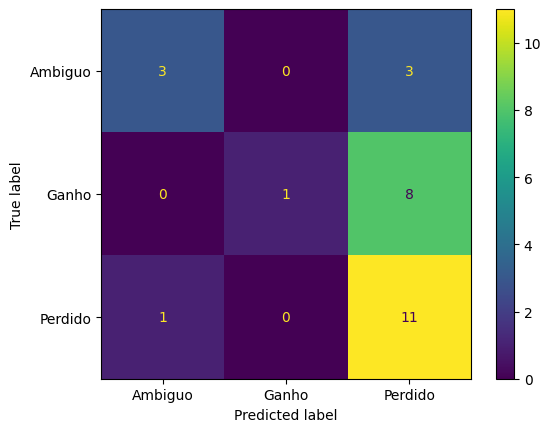

In [110]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree


Cross-Validation Results: [0.62962963 0.85185185 0.7037037  0.66666667 0.73076923]
Mean F1 Score: 0.7165242165242165


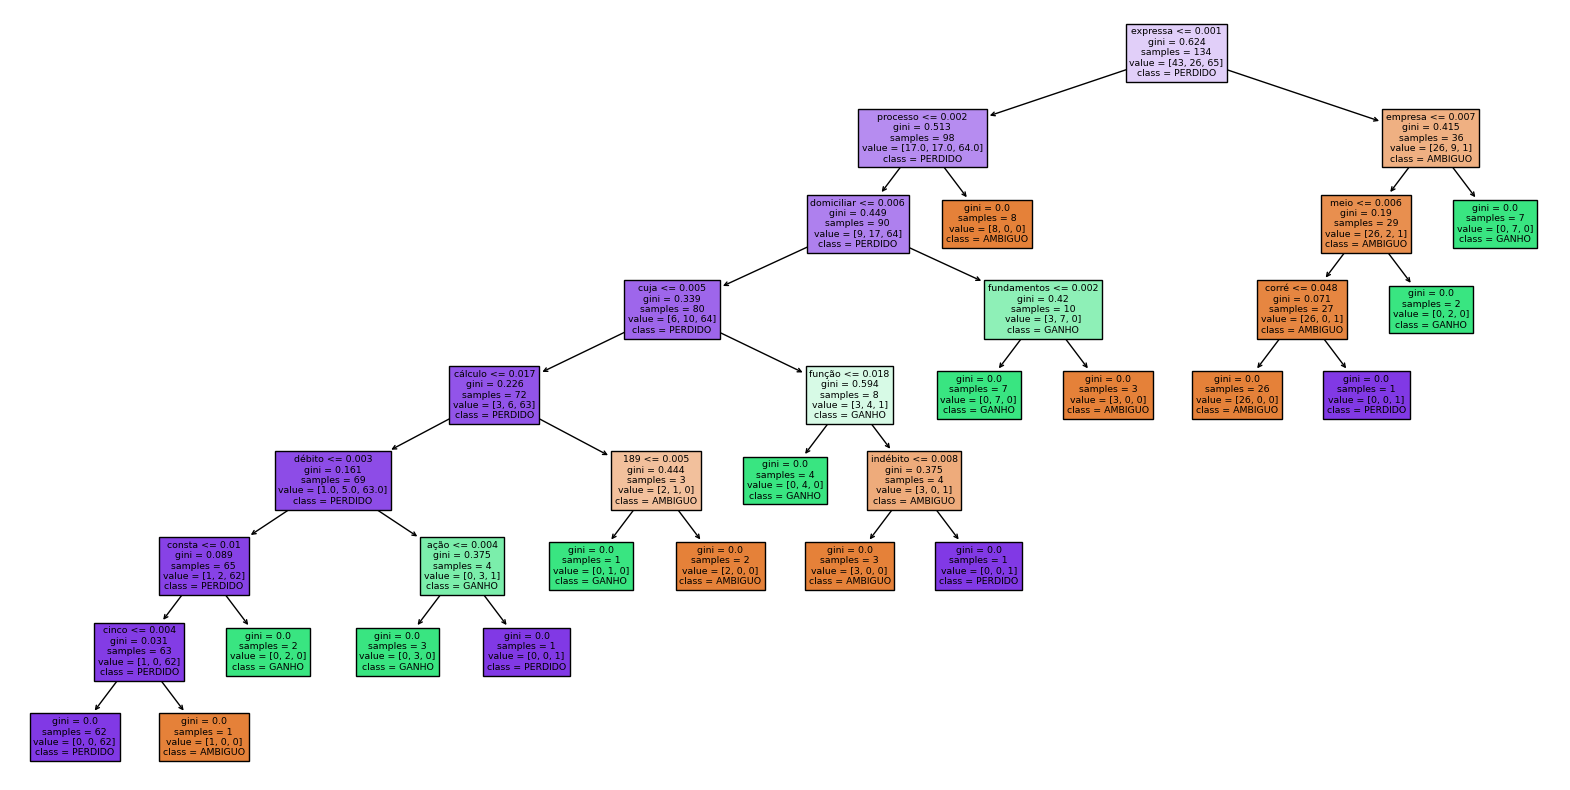

In [112]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Create the decision tree classifier
model = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')

# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

# Fit the decision tree classifier on the entire dataset
model.fit(X, y)

# Plot the decision tree
plt.figure(figsize=(20, 10))  # Adjust the figure size as needed
plot_tree(model, feature_names=vocab.split() ,class_names=["AMBIGUO", "GANHO", "PERDIDO"], filled=True)

plt.show()
